# Conos advanced: alignment spaces, memory, modalities, label transfer

This tutorial assumes you have been through the
[walkthrough](conos-walkthrough.ipynb) and covers the knobs that matter
when integration is harder: **which space** to align in, **how
aggressively** to align, **memory** on large panels, **what the samples
actually share** (modalities/features), and **label-transfer** choices.
We reuse the same bone-marrow / cord-blood panel.

In [ ]:
library(conos)
library(pagoda2)
library(conosPanel)

set.seed(1)
n.cores <- 4
panel <- lapply(conosPanel::panel, function(m) m[, sample(ncol(m), min(1000, ncol(m)))])  # subsample for speed
samples <- lapply(panel, function(cm) {
  rownames(cm) <- make.unique(rownames(cm))
  p <- Pagoda2$from(cm, n.cores = n.cores, min.cells.per.gene = 0, min.transcripts.per.cell = 0,
                    log.scale = TRUE, verbose = FALSE)
  p$run(steps = c("variance", "pca"), dependencies = "error", verbose = FALSE)   # just the reduction
  p
})
con <- Conos$new(samples, n.cores = n.cores)

## 1. Plan the integration first

`planIntegration()` is a read-only preliminary step. It polls each
sample’s molecular modalities (here just RNA; for multimodal samples it
would list ADT/ATAC facets too) and, per modality, reports how many
features are shared across the samples and how well they overlap — with
a *usable / marginal / not-integrable* verdict. This is where you catch
problems like independently-called scATAC peaks that simply cannot be
reconciled without re-processing.

In [ ]:
plan <- con$planIntegration()

Integration plan — 4 samples

 modality samples common.features overlap.min overlap.med verdict
      RNA     4/4           33694           1           1  usable

common default modality: RNA — buildGraph() integrates on it

  modality samples common.features overlap.min overlap.med verdict
1      RNA     4/4           33694           1           1  usable

The resolved default modality is recorded on the object and is what
`runGraph()` aligns on unless you tell it otherwise.

## 2. Choosing the alignment space

The `space` argument controls how each pair of samples is matched:

- **`"PCA"` (default)** — *reciprocal PCA*: each sample’s PCA loadings
  define a shared gene basis both samples project into. Fast and robust;
  the right default for most panels.
- **`"CCA"`** — canonical correlation. Useful for **heterogeneous**
  integrations (very different compositions), but heavier and prone to
  **over-smoothing** (merging distinct populations) when little
  correction is actually needed.
- **`"CPCA"`** — common principal components; available, but in practice
  much slower without a clear gain over reciprocal PCA, so it is not the
  default.

In [ ]:
con$runGraph(k = 20, k.self = 5, space = "PCA", ncomps = 30, n.odgenes = 2000, verbose = FALSE)
con$runClustering(name = "leiden_pca", verbose = FALSE)

con$runGraph(k = 20, k.self = 5, space = "CCA", ncomps = 30, n.odgenes = 2000, verbose = FALSE)
con$runClustering(name = "leiden_cca", verbose = FALSE)

c(PCA = length(unique(con$clusters$leiden_pca$groups)),
  CCA = length(unique(con$clusters$leiden_cca$groups)))

PCA CCA 
 10   7 

CCA typically yields a more aggressively mixed graph (often fewer,
larger clusters). Inspect both and pick the one whose mixing matches
your biological expectation rather than trusting a single default.

`alignment.strength` (and `k`/`k1`) tune how forcefully samples are
pulled together — raise it for stronger batch correction, lower it to
preserve subtle structure.

## 3. Memory on large panels

The per-pair alignment rotations are O(samples²) and dominate memory on
big panels. `pairs.storage` controls them: `"keep"` (default) retains
them in RAM for reuse, `"drop"` discards them after the graph is built
(a later `runGraph()` recomputes), and `"disk"` offloads them to a
scratch file — freed from RAM but restored on the next `runGraph()` so
re-runs are cheap.

The disk path costs almost nothing in time (the rotations are written
once after the graph is built), so on large panels it is essentially
free memory:

In [ ]:
t_keep <- system.time(con$runGraph(k = 20, k.self = 5, space = "PCA", ncomps = 30, n.odgenes = 2000,
                                   pairs.storage = "keep", verbose = FALSE))["elapsed"]
rot_mb  <- as.numeric(object.size(con$pairs[["PCA"]])) / 1e6     # rotation RAM held under "keep"

t_disk <- system.time(con$runGraph(k = 20, k.self = 5, space = "PCA", ncomps = 30, n.odgenes = 2000,
                                   pairs.storage = "disk", verbose = FALSE))["elapsed"]

c(keep_s = round(t_keep, 2), disk_s = round(t_disk, 2),
  rotation_RAM_freed_MB = round(rot_mb, 1), pairs_in_RAM_after_disk = length(con$pairs[["PCA"]]))

         keep_s.elapsed          disk_s.elapsed   rotation_RAM_freed_MB 
                   2.80                    3.03                    3.70 
pairs_in_RAM_after_disk 
                   0.00 

`runClustering()` / `runEmbedding()` work the same way regardless of
`pairs.storage`. On a four-sample panel the freed RAM is small, but it
grows as the square of the number of samples, so `"disk"` is the right
choice for large atlases. (On lstar-backed pagoda2 samples the build
path also streams expression in gene blocks, keeping the per-sample
footprint flat as well.)

In [ ]:
con$runClustering(verbose = FALSE)

## 4. Choosing a clustering resolution

`scanResolution()` runs the community detection over a range of
resolutions and reports the number of clusters (and modularity), helping
you pick a value rather than guessing:

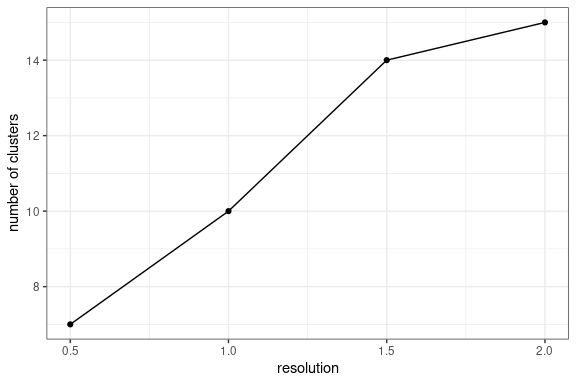

  resolution n.clusters modularity
1        0.5          7  0.7560577
2        1.0         10  0.7603385
3        1.5         14  0.7562323
4        2.0         15  0.7232798

In [ ]:
res <- scanResolution(con, resolutions = c(0.5, 1, 1.5, 2), plot = TRUE, verbose = FALSE)

In [ ]:
con$runClustering(resolution = 1.5, name = "leiden_r15", verbose = FALSE)

## 5. Label transfer: diffusion vs solver

`propagateLabels()` offers two engines. On real panels they give
near-identical results; the difference is scaling:

- **`"diffusion"` (default)** — iterative graph diffusion. Scales to
  very large panels.
- **`"solver"`** — a Zhu–Ghahramani–Lafferty harmonic solve. Fast and
  slightly more accurate at typical sizes, but its linear solve does not
  scale much beyond ~20k cells.

In [ ]:
groups <- con$clusters$leiden_pca$groups
set.seed(1)
reference <- groups[sample(length(groups), round(0.30 * length(groups)))]
held.out  <- setdiff(names(groups), names(reference))

td <- con$propagateLabels(labels = reference, method = "diffusion", verbose = FALSE)
ts <- con$propagateLabels(labels = reference, method = "solver", solver = "Matrix")

c(diffusion = mean(td$labels[held.out] == as.character(groups[held.out])),
  solver    = mean(ts$labels[held.out] == as.character(groups[held.out])),
  agreement = mean(td$labels[held.out] == ts$labels[held.out]))

diffusion    solver agreement 
0.9553571 0.9582143 0.9892857 

Use `diffusion` (the default) for very large atlases and `solver` when
the panel is modest and you want the extra speed/accuracy.

## 6. Multimodal panels (facets)

When samples carry more than one molecular modality (e.g. RNA + ADT in
CITE-seq, or RNA + ATAC in multiome, produced with pagoda2.1 *facets*),
`planIntegration()` polls and assesses **each** modality separately, so
you can see which ones are actually integrable across the panel before
committing. Today Conos aligns on a single shared modality (the common
default, usually RNA) — the recommended, robust path — and
modality-aware accessors (`getModalities()`, `getDefaultModality()`)
expose the rest. Joint multimodal *fusion* (weighting modalities per
cell, à la WNN) is the next step on the roadmap.

## Recap

`planIntegration()` to see what’s realistic →
`runGraph(space=, alignment.strength=, pairs.storage=)` to control the
alignment and memory → `scanResolution()` + `runClustering(resolution=)`
to tune granularity → `propagateLabels(method=)` to transfer
annotations. Start from the [walkthrough](conos-walkthrough.ipynb)
defaults and reach for these only when a particular integration needs
them.